Cell 1 — Imports

In [1]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from src.utils.data_loader import load_dataset
from src.pipeline.base import ArabicTextPipeline
from src.pipeline.steps import (
    DiacriticsRemover,
    Normalizer,
    ElongationNormalizer,
    PunctuationRemover,
    StopwordRemover,
)
from src.utils.experiment import run_experiment, results_to_dataframe

Cell 2 — Load datasets

In [2]:
hard_df = load_dataset("hard")
twitter_df = load_dataset("twitter")

print("HARD:", hard_df.shape, hard_df["label"].value_counts().to_dict())
print("Twitter:", twitter_df.shape, twitter_df["label"].value_counts().to_dict())

HARD: (99999, 3) {'Positive': 33333, 'Mixed': 33333, 'Negative': 33333}
Twitter: (56795, 4) {'Positive': 28513, 'Negative': 28282}


Cell 3 — Build pipeline

In [3]:
pipeline = ArabicTextPipeline([
    DiacriticsRemover(),
    Normalizer(),
    ElongationNormalizer(),
    PunctuationRemover(),
    StopwordRemover(),
])

print("Pipeline steps:", pipeline.describe())

Pipeline steps: ['DiacriticsRemover()', 'Normalizer()', 'ElongationNormalizer()', 'PunctuationRemover()', 'StopwordRemover()']


Cell 4 — Preview preprocessing

In [4]:
samples = hard_df["text"].sample(3, random_state=42).tolist()

for text in samples:
    print("BEFORE:", text[:100])
    print("AFTER :", pipeline.transform(text)[:100])
    print()

BEFORE: أقم على الماشي . بصورة عامة الغرفة جيدة وكل شيء متوفر فيها. عدم وجود ستارة الحمام
AFTER : اقم علا الماشي بصوره عامه الغرفه جيده وكل شيء متوفر فيها عدم وجود ستاره الحمام

BEFORE: لم تعجبني كباقي السلسلة و غير متحمس لقراءة الجزء الثاني منها
AFTER : تعجبني كباقي السلسله و متحمس لقراءه الجزء الثاني منها

BEFORE: كان المكان ممتاز والأمن والاستقبال اوكي . . التكييف كان حار وبلغت اكثر من مره يتم له صيانه ولكن دون 
AFTER : المكان ممتاز والامن والاستقبال اوكي التكييف حار وبلغت اكثر مره يتم له صيانه ولكن دون جدوي بالاضافه ا



Cell 5 — Run the Experiments

In [6]:
all_results = []

# HARD dataset - word mode
results = run_experiment(hard_df, pipeline, "HARD", vectorizer_mode="word")
all_results.extend(results)

# Twitter dataset - word mode  
results = run_experiment(twitter_df, pipeline, "Twitter", vectorizer_mode="word")
all_results.extend(results)


Dataset: HARD | Vectorizer: word
Preprocessing...
Vectorizing...
Vocabulary size: 15000
Training LogisticRegression...


c:\Users\Phoenix\Documents\VS_Code_Projects\arabic-nlp-pipeline\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1457: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


  F1 macro: 0.6710 | F1 weighted: 0.6710
Training LinearSVC...
  F1 macro: 0.6495 | F1 weighted: 0.6495
Training RandomForest...
  F1 macro: 0.6374 | F1 weighted: 0.6374

Dataset: Twitter | Vectorizer: word
Preprocessing...
Vectorizing...
Vocabulary size: 15000
Training LogisticRegression...


c:\Users\Phoenix\Documents\VS_Code_Projects\arabic-nlp-pipeline\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1457: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


  F1 macro: 0.7698 | F1 weighted: 0.7697
Training LinearSVC...
  F1 macro: 0.7715 | F1 weighted: 0.7715
Training RandomForest...
  F1 macro: 0.7924 | F1 weighted: 0.7923


Cell 6 — results table

In [7]:
results_df = results_to_dataframe(all_results)
print(results_df.to_string(index=False))
results_df.to_csv("../results/experiment_results.csv", index=False)
print("\nSaved to results/experiment_results.csv")

dataset              model vectorizer  f1_macro  f1_weighted
   HARD LogisticRegression       word    0.6710       0.6710
   HARD          LinearSVC       word    0.6495       0.6495
   HARD       RandomForest       word    0.6374       0.6374
Twitter LogisticRegression       word    0.7698       0.7697
Twitter          LinearSVC       word    0.7715       0.7715
Twitter       RandomForest       word    0.7924       0.7923

Saved to results/experiment_results.csv


Cell 7 — visualize

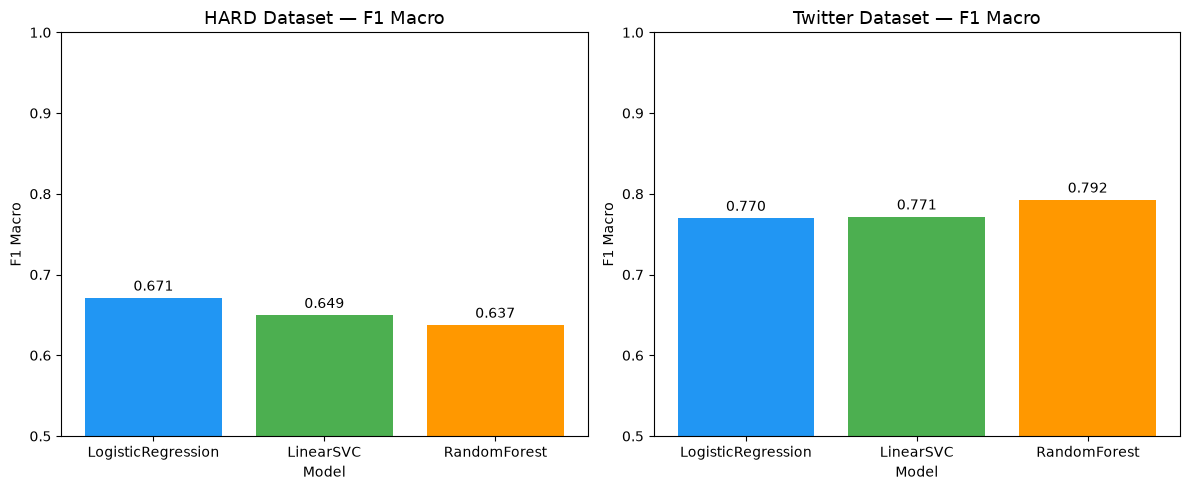

Saved to results/experiment_results.png


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, dataset in zip(axes, ["HARD", "Twitter"]):
    subset = results_df[results_df["dataset"] == dataset]
    bars = ax.bar(subset["model"], subset["f1_macro"], color=["#2196F3", "#4CAF50", "#FF9800"])
    ax.set_title(f"{dataset} Dataset — F1 Macro", fontsize=13)
    ax.set_ylim(0.5, 1.0)
    ax.set_ylabel("F1 Macro")
    ax.set_xlabel("Model")
    for bar, val in zip(bars, subset["f1_macro"]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f"{val:.3f}", ha="center", va="bottom", fontsize=10)

plt.tight_layout()
plt.savefig("../results/experiment_results.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved to results/experiment_results.png")